In [415]:
import pandas as pd

fed_files = ["MORTGAGE30US.csv", "RRVRUSQ156N.csv", "CPIAUCSL.csv"]

dfs = [pd.read_csv(f, parse_dates=True, index_col=0) for f in fed_files]

In [416]:
dfs[0]

,MORTGAGE30US
observation_date,
1971-04-02,7.33
1971-04-09,7.31
1971-04-16,7.31
1971-04-23,7.31
1971-04-30,7.29
...,...
2026-03-05,6.00
2026-03-12,6.11
2026-03-19,6.22


In [417]:
dfs[1]

,RRVRUSQ156N
observation_date,
1956-01-01,6.2
1956-04-01,5.9
1956-07-01,6.3
1956-10-01,5.8
1957-01-01,5.3
...,...
2024-10-01,6.9
2025-01-01,7.1
2025-04-01,7.0


In [418]:
fed_data = pd.concat(dfs, axis=1)

In [419]:
fed_data

,MORTGAGE30US,RRVRUSQ156N,CPIAUCSL
observation_date,,,
1947-01-01,NaN,NaN,21.48
1947-02-01,NaN,NaN,21.62
1947-03-01,NaN,NaN,22.00
1947-04-01,NaN,NaN,22.00
1947-05-01,NaN,NaN,21.95
...,...,...,...
2026-03-05,6.00,NaN,NaN
2026-03-12,6.11,NaN,NaN
2026-03-19,6.22,NaN,NaN


In [420]:
fed_data = fed_data.ffill()

In [421]:
fed_data.tail(50)

,MORTGAGE30US,RRVRUSQ156N,CPIAUCSL
observation_date,,,
2025-06-18,6.81,7.0,321.435
2025-06-26,6.77,7.0,321.435
2025-07-01,6.77,7.1,322.169
2025-07-03,6.67,7.1,322.169
2025-07-10,6.72,7.1,322.169
2025-07-17,6.75,7.1,322.169
2025-07-24,6.74,7.1,322.169
2025-07-31,6.72,7.1,322.169
2025-08-01,6.72,7.1,323.291


In [422]:
zillow_files = ["Metro_median_sale_price_uc_sfrcondo_sm_week.csv", "Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"]

dfs = [pd.read_csv(f) for f in zillow_files]

In [423]:
dfs[0]

,RegionID,SizeRank,RegionName,RegionType,StateName,2008-02-23,2008-03-01,2008-03-08,2008-03-15,2008-03-22,...,2025-12-06,2025-12-13,2025-12-20,2025-12-27,2026-01-03,2026-01-10,2026-01-17,2026-01-24,2026-01-31,2026-02-07
0,102001,0,United States,country,NaN,169750.0,169750.0,171200.0,172450.0,174700.0,...,361350.0,358875.0,358725.0,357850.0,354100.0,352850.0,350375.0,349000.0,350250.0,350250.0
1,394913,1,"New York, NY",msa,NY,398857.0,398607.0,395407.0,391250.0,390000.0,...,659594.0,652094.0,651781.0,649281.0,647750.0,650125.0,653581.0,658581.0,663581.0,667456.0
2,753899,2,"Los Angeles, CA",msa,CA,468250.0,469750.0,469750.0,467500.0,457750.0,...,938375.0,936750.0,933750.0,925000.0,922500.0,922375.0,926125.0,926125.0,918125.0,905625.0
3,394463,3,"Chicago, IL",msa,IL,217125.0,216625.0,212875.0,211375.0,214625.0,...,322813.0,320313.0,320313.0,318063.0,311250.0,311313.0,311313.0,315063.0,317563.0,317500.0
4,394514,4,"Dallas, TX",msa,TX,136063.0,136813.0,140688.0,141488.0,141948.0,...,376280.0,375030.0,372750.0,369625.0,365000.0,363750.0,365000.0,365313.0,367425.0,370738.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,395066,284,"Santa Fe, NM",msa,NM,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,581550.0,615264.0,592827.0,572202.0,574202.0
200,394685,289,"Homosassa Springs, FL",msa,FL,NaN,NaN,NaN,NaN,NaN,...,245263.0,257763.0,272775.0,278025.0,280000.0,274688.0,263188.0,270688.0,265563.0,267125.0
201,395153,329,"The Villages, FL",msa,FL,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,387125.0,372375.0,365813.0,364688.0,360438.0,374188.0
202,394905,341,"New Bern, NC",msa,NC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,269563.0,274063.0,284313.0,280688.0,272875.0,271000.0


In [424]:
dfs = [pd.DataFrame(df.iloc[1,5:]) for df in dfs]

In [425]:
dfs[0]

,1
2008-02-23,398857.0
2008-03-01,398607.0
2008-03-08,395407.0
2008-03-15,391250.0
2008-03-22,390000.0
...,...
2026-01-10,650125.0
2026-01-17,653581.0
2026-01-24,658581.0
2026-01-31,663581.0


In [426]:
for df in dfs:
  df.index = pd.to_datetime(df.index)
  df["month"] = df.index.to_period("M")

In [427]:
dfs[0]

,1,month
2008-02-23,398857.0,2008-02
2008-03-01,398607.0,2008-03
2008-03-08,395407.0,2008-03
2008-03-15,391250.0,2008-03
2008-03-22,390000.0,2008-03
...,...,...
2026-01-10,650125.0,2026-01
2026-01-17,653581.0,2026-01
2026-01-24,658581.0,2026-01
2026-01-31,663581.0,2026-01


In [428]:
price_data = dfs[0].merge(dfs[1], on="month")

In [429]:
price_data.index = dfs[0].index

In [430]:
price_data

,1_x,month,1_y
2008-02-23,398857.0,2008-02,451918.962286
2008-03-01,398607.0,2008-03,450190.511373
2008-03-08,395407.0,2008-03,450190.511373
2008-03-15,391250.0,2008-03,450190.511373
2008-03-22,390000.0,2008-03,450190.511373
...,...,...,...
2026-01-10,650125.0,2026-01,703346.479016
2026-01-17,653581.0,2026-01,703346.479016
2026-01-24,658581.0,2026-01,703346.479016
2026-01-31,663581.0,2026-01,703346.479016


In [431]:
del price_data["month"]
price_data.columns = ["price", "value"]

In [432]:
price_data

,price,value
2008-02-23,398857.0,451918.962286
2008-03-01,398607.0,450190.511373
2008-03-08,395407.0,450190.511373
2008-03-15,391250.0,450190.511373
2008-03-22,390000.0,450190.511373
...,...,...
2026-01-10,650125.0,703346.479016
2026-01-17,653581.0,703346.479016
2026-01-24,658581.0,703346.479016
2026-01-31,663581.0,703346.479016


In [433]:
fed_data = fed_data.dropna()

In [434]:
fed_data

,MORTGAGE30US,RRVRUSQ156N,CPIAUCSL
observation_date,,,
1971-04-02,7.33,5.3,40.10
1971-04-09,7.31,5.3,40.10
1971-04-16,7.31,5.3,40.10
1971-04-23,7.31,5.3,40.10
1971-04-30,7.29,5.3,40.10
...,...,...,...
2026-03-05,6.00,7.2,327.46
2026-03-12,6.11,7.2,327.46
2026-03-19,6.22,7.2,327.46


In [435]:
from datetime import timedelta

fed_data.index = fed_data.index + timedelta(days=2)

In [436]:
fed_data

,MORTGAGE30US,RRVRUSQ156N,CPIAUCSL
observation_date,,,
1971-04-04,7.33,5.3,40.10
1971-04-11,7.31,5.3,40.10
1971-04-18,7.31,5.3,40.10
1971-04-25,7.31,5.3,40.10
1971-05-02,7.29,5.3,40.10
...,...,...,...
2026-03-07,6.00,7.2,327.46
2026-03-14,6.11,7.2,327.46
2026-03-21,6.22,7.2,327.46


In [437]:
price_data =a = fed_data.merge(price_data, left_index=True, right_index=True)

In [438]:
price_data.columns = ["interest", "vacancy", "cpi", "price", "value"]

In [439]:
price_data

,interest,vacancy,cpi,price,value
2008-02-23,6.04,10.1,212.687,398857.0,451918.962286
2008-03-01,6.24,10.1,212.687,398607.0,450190.511373
2008-03-08,6.03,10.1,213.448,395407.0,450190.511373
2008-03-15,6.13,10.1,213.448,391250.0,450190.511373
2008-03-22,5.87,10.1,213.448,390000.0,450190.511373
...,...,...,...,...,...
2026-01-10,6.16,7.2,326.588,650125.0,703346.479016
2026-01-17,6.06,7.2,326.588,653581.0,703346.479016
2026-01-24,6.09,7.2,326.588,658581.0,703346.479016
2026-01-31,6.10,7.2,326.588,663581.0,703346.479016


In [440]:
price_data

,interest,vacancy,cpi,price,value
2008-02-23,6.04,10.1,212.687,398857.0,451918.962286
2008-03-01,6.24,10.1,212.687,398607.0,450190.511373
2008-03-08,6.03,10.1,213.448,395407.0,450190.511373
2008-03-15,6.13,10.1,213.448,391250.0,450190.511373
2008-03-22,5.87,10.1,213.448,390000.0,450190.511373
...,...,...,...,...,...
2026-01-10,6.16,7.2,326.588,650125.0,703346.479016
2026-01-17,6.06,7.2,326.588,653581.0,703346.479016
2026-01-24,6.09,7.2,326.588,658581.0,703346.479016
2026-01-31,6.10,7.2,326.588,663581.0,703346.479016


<Axes: >

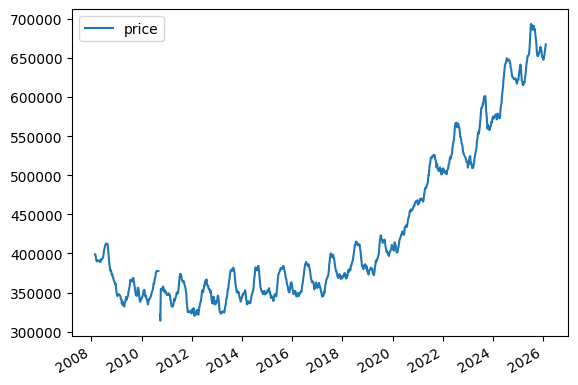

In [441]:
price_data.plot.line(y="price", use_index=True)

In [442]:
price_data["adj_price"] = price_data["price"] / price_data["cpi"] * 100

<Axes: >

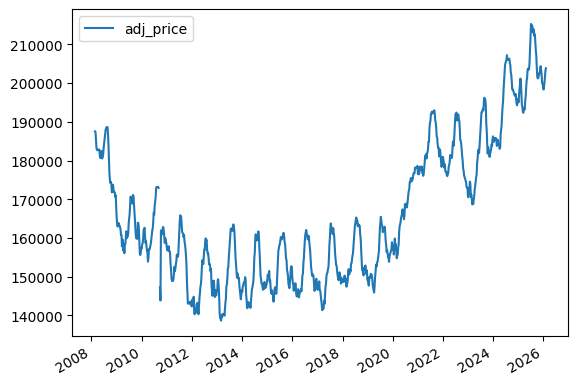

In [443]:
price_data.plot.line(y="adj_price", use_index=True)

In [444]:
price_data["adj_value"] = price_data["value"] / price_data["cpi"] * 100

In [445]:
price_data["next_quarter"] = price_data["adj_price"].shift(-13)

In [446]:
price_data.dropna(inplace=True)

In [447]:
price_data

,interest,vacancy,cpi,price,value,adj_price,adj_value,next_quarter
2008-02-23,6.04,10.1,212.687,398857.0,451918.962286,187532.383267,212480.763886,182381.695848
2008-03-01,6.24,10.1,212.687,398607.0,450190.511373,187414.839647,211668.090374,182417.01052
2008-03-08,6.03,10.1,213.448,395407.0,450190.511373,185247.46074,210913.436234,180525.422716
2008-03-15,6.13,10.1,213.448,391250.0,450190.511373,183299.913796,210913.436234,181100.233143
2008-03-22,5.87,10.1,213.448,390000.0,450190.511373,182714.291069,210913.436234,181675.043571
...,...,...,...,...,...,...,...,...
2025-09-27,6.30,7.1,324.245,661250.0,691291.361808,203935.295841,213200.315135,199065.795436
2025-10-04,6.34,7.2,324.245,653750.0,693606.472034,201622.230104,213914.31542,200124.009455
2025-10-11,6.30,7.2,324.245,652488.0,693606.472034,201233.018242,213914.31542,201654.990385
2025-10-18,6.27,7.2,324.245,652488.0,693606.472034,201233.018242,213914.31542,203185.971316


In [448]:
price_data["change"] = (price_data["next_quarter"] > price_data["adj_price"]).astype(int)

In [449]:
price_data

,interest,vacancy,cpi,price,value,adj_price,adj_value,next_quarter,change
2008-02-23,6.04,10.1,212.687,398857.0,451918.962286,187532.383267,212480.763886,182381.695848,0
2008-03-01,6.24,10.1,212.687,398607.0,450190.511373,187414.839647,211668.090374,182417.01052,0
2008-03-08,6.03,10.1,213.448,395407.0,450190.511373,185247.46074,210913.436234,180525.422716,0
2008-03-15,6.13,10.1,213.448,391250.0,450190.511373,183299.913796,210913.436234,181100.233143,0
2008-03-22,5.87,10.1,213.448,390000.0,450190.511373,182714.291069,210913.436234,181675.043571,0
...,...,...,...,...,...,...,...,...,...
2025-09-27,6.30,7.1,324.245,661250.0,691291.361808,203935.295841,213200.315135,199065.795436,0
2025-10-04,6.34,7.2,324.245,653750.0,693606.472034,201622.230104,213914.31542,200124.009455,0
2025-10-11,6.30,7.2,324.245,652488.0,693606.472034,201233.018242,213914.31542,201654.990385,1
2025-10-18,6.27,7.2,324.245,652488.0,693606.472034,201233.018242,213914.31542,203185.971316,1


In [450]:
price_data["change"].value_counts()

,count
change,
0,469
1,426


In [451]:
predictors = ["interest", "vacancy", "adj_price", "adj_value"]
target = "change"

In [452]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

In [453]:
START = 260
STEP = 52

def predict(train, test, predictors, target):
  rf = RandomForestClassifier(min_samples_split=10, random_state=1)
  rf.fit(train[predictors], train[target])
  preds = rf.predict(test[predictors])
  return preds

def backtest(data, predictors, target):
  all_preds = []
  for i in range(START, data.shape[0], STEP):
    train = price_data.iloc[:i]
    test = price_data.iloc[i:(i+STEP)]
    all_preds.append(predict(train, test, predictors, target))

  preds = np.concatenate(all_preds)
  return preds, accuracy_score(data.iloc[START:][target], preds)

In [454]:
preds, accuracy = backtest(price_data, predictors, target)

In [455]:
accuracy

0.6236220472440945

In [456]:
yearly = price_data.rolling(52, min_periods=1).mean()

In [457]:
yearly

,interest,vacancy,cpi,price,value,adj_price,adj_value,next_quarter,change
2008-02-23,6.040000,10.100000,212.687000,398857.000000,451918.962286,187532.383267,212480.763886,182381.695848,0.000000
2008-03-01,6.140000,10.100000,212.687000,398732.000000,451054.736830,187473.611457,212074.427130,182399.353184,0.000000
2008-03-08,6.103333,10.100000,212.940667,397623.666667,450766.661677,186731.561218,211687.430165,181774.709694,0.000000
2008-03-15,6.110000,10.100000,213.067500,396030.250000,450622.624101,185873.649363,211493.931682,181606.090557,0.000000
2008-03-22,6.062000,10.100000,213.143600,394824.200000,450536.201556,185241.777704,211377.832592,181619.881159,0.000000
...,...,...,...,...,...,...,...,...,...
2025-09-27,6.675769,7.023077,319.805423,644942.423077,682938.199776,201628.840280,213547.661953,202606.486408,0.442308
2025-10-04,6.680577,7.028846,319.988365,645281.365385,683387.925992,201619.336939,213566.213111,202688.845010,0.442308
2025-10-11,6.684808,7.034615,320.171308,645692.192308,683837.652209,201632.899779,213584.764269,202816.668533,0.461538
2025-10-18,6.687692,7.040385,320.336962,646199.173077,684219.655630,201687.910388,213593.523273,202940.773446,0.480769


In [458]:
yearly_ratios = [p + "_year" for p in predictors]
price_data[yearly_ratios] = price_data[predictors] / yearly[predictors]

In [459]:
price_data

,interest,vacancy,cpi,price,value,adj_price,adj_value,next_quarter,change,interest_year,vacancy_year,adj_price_year,adj_value_year
2008-02-23,6.04,10.1,212.687,398857.0,451918.962286,187532.383267,212480.763886,182381.695848,0,1.000000,1.000000,1.0,1.0
2008-03-01,6.24,10.1,212.687,398607.0,450190.511373,187414.839647,211668.090374,182417.01052,0,1.016287,1.000000,0.999687,0.998084
2008-03-08,6.03,10.1,213.448,395407.0,450190.511373,185247.46074,210913.436234,180525.422716,0,0.987985,1.000000,0.992052,0.996344
2008-03-15,6.13,10.1,213.448,391250.0,450190.511373,183299.913796,210913.436234,181100.233143,0,1.003273,1.000000,0.986153,0.997255
2008-03-22,5.87,10.1,213.448,390000.0,450190.511373,182714.291069,210913.436234,181675.043571,0,0.968327,1.000000,0.986356,0.997803
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-27,6.30,7.1,324.245,661250.0,691291.361808,203935.295841,213200.315135,199065.795436,0,0.943711,1.010953,1.011439,0.998373
2025-10-04,6.34,7.2,324.245,653750.0,693606.472034,201622.230104,213914.31542,200124.009455,0,0.949020,1.024350,1.000014,1.00163
2025-10-11,6.30,7.2,324.245,652488.0,693606.472034,201233.018242,213914.31542,201654.990385,1,0.942435,1.023510,0.998017,1.001543
2025-10-18,6.27,7.2,324.245,652488.0,693606.472034,201233.018242,213914.31542,203185.971316,1,0.937543,1.022671,0.997745,1.001502


In [460]:
preds, accuracy = backtest(price_data, predictors + yearly_ratios, target)

In [461]:
accuracy

0.6125984251968504

In [462]:
pred_match = (preds == price_data[target].iloc[START:])

In [463]:
pred_match = pred_match.map({True: "green", False: "red"})


<Axes: xlabel='index', ylabel='adj_price'>

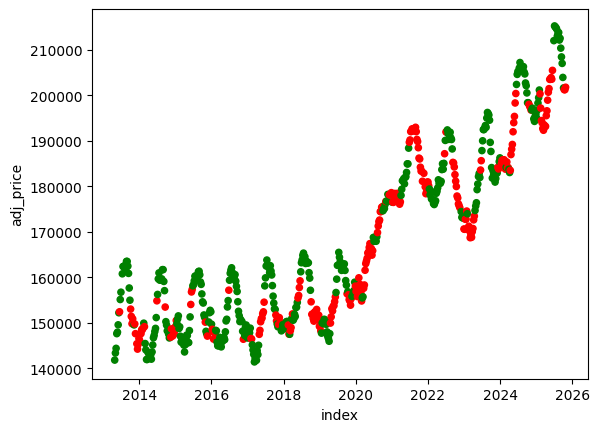

In [464]:
import matplotlib.pyplot as plt

plot_data = price_data.iloc[START:].copy()
plot_data = plot_data.reset_index()
plot_data["color"] = pred_match.values  # attach colors

plot_data.plot.scatter(
    x="index",
    y="adj_price",
    c=plot_data["color"]   # 🔥 THIS is the fix
)

In [465]:
from sklearn.inspection import permutation_importance

rf = RandomForestClassifier(min_samples_split=10, random_state=1)
rf.fit(price_data[predictors], price_data[target])

result = permutation_importance(rf, price_data[predictors], price_data[target], n_repeats=10, random_state=1)

In [466]:
result["importances_mean"]

array([0.10223464, 0.22413408, 0.34379888, 0.26759777])

In [467]:
predictors

['interest', 'vacancy', 'adj_price', 'adj_value']